#### **Newcastle Urban Heat Vulnerability Index (UHVI) GeoXAI Analysis**

1. UHVI analysis and visualization
2. XGBoost modelling and evaluation
3. SHAP GeoXAI analysis and visualization
4. Adaptation scenarios and visualization
5. Intervention priority and visualization

**1. UHVI analysis and visualization**

In [154]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [155]:
# Install and import packages

!pip install geopandas pyogrio xgboost shap scikit-learn mapclassify -q

In [156]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

import shap

In [157]:
# Load final UHVI dataset

base_dir = "/content/drive/MyDrive/LST_Project"
output_dir = f"{base_dir}/outputs"
figure_dir = f"{base_dir}/figures"
model_dir = f"{base_dir}/models"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(figure_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

uhvi_gpkg = f"{output_dir}/newcastle_full_uhvi.gpkg"

lsoa = gpd.read_file(uhvi_gpkg)

print("Rows:", len(lsoa))
print("CRS:", lsoa.crs)
print(lsoa.columns.tolist())

Rows: 180
CRS: EPSG:27700
['LSOA21CD', 'LSOA21NM_x', 'LSOA21NMW_x', 'BNG_E_x', 'BNG_N_x', 'LAT_x', 'LONG_x', 'Shape__Area', 'Shape__Length', 'GlobalID_x', 'LSOA21NM_y', 'LSOA21NMW_y', 'BNG_E_y', 'BNG_N_y', 'LAT_y', 'LONG_y', 'Shape__Are', 'Shape__Len', 'GlobalID_y', 'lst_max', 'lst_mean', 'lst_px_count', 'lst_median', 'lst_p95', 'gi_z', 'gi_p', 'hotspot_class', 'ndvi_mean', 'ndbi_mean', 'impervious_pct', 'green_pct', 'tree_canopy_pct', 'lsoa_area_m2', 'road_length_m', 'road_density_km_per_km2', 'built_up_index', 'built_up_density_proxy', 'LSOA11CD', 'imd_score', 'imd_rank', 'imd_decile', 'income_score', 'health_deprivation_score', 'hotspot_binary', 'lst_mean_norm', 'lst_p95_norm', 'hotspot_binary_norm', 'population_density', 'age_65_pct', 'age_75_pct', 'disability_pct', 'age_65_pct_norm', 'age_75_pct_norm', 'disability_pct_norm', 'health_deprivation_score_norm', 'population_density_norm', 'tree_canopy_pct_norm', 'green_pct_norm', 'income_score_norm', 'exposure_index', 'sensitivity_inde

In [158]:
# Basic UHVI checks

print(lsoa["uhvi"].describe())
print(lsoa["uhvi_class"].value_counts())

count    180.000000
mean       0.528307
std        0.189097
min        0.000000
25%        0.412105
50%        0.500963
75%        0.667817
max        1.000000
Name: uhvi, dtype: float64
uhvi_class
Low          36
High         36
Moderate     36
Very High    36
Very Low     36
Name: count, dtype: int64


In [159]:
# Top 20 most vulnerable LSOAs

name_col = "LSOA21NM_x" if "LSOA21NM_x" in lsoa.columns else "LSOA21NM"

top20 = (
    lsoa[
        [
            "LSOA21CD",
            name_col,
            "uhvi",
            "uhvi_class",
            "lst_mean",
            "lst_p95",
            "tree_canopy_pct",
            "green_pct",
            "imd_score",
            "health_deprivation_score",
            "population_density",
            "age_65_pct",
            "disability_pct"
        ]
    ]
    .sort_values("uhvi", ascending=False)
    .head(20)
)

display(top20)

,LSOA21CD,LSOA21NM_x,uhvi,uhvi_class,lst_mean,lst_p95,tree_canopy_pct,green_pct,imd_score,health_deprivation_score,population_density,age_65_pct,disability_pct
174,E01035618,Newcastle upon Tyne 038B,1.000000,Very High,36.552954,37.472785,3.835227,13.636364,NaN,NaN,25921.7,2.517306,14.033984
69,E01008361,Newcastle upon Tyne 018D,0.974381,Very High,35.318147,36.368850,0.361991,2.714932,22.497,1.004,15279.8,5.193076,19.174434
67,E01008359,Newcastle upon Tyne 018B,0.972402,Very High,35.720111,36.568804,0.739523,6.655711,21.127,0.892,12737.1,5.460993,17.943262
70,E01008362,Newcastle upon Tyne 018E,0.963192,Very High,35.200332,36.723640,5.435651,12.390088,21.450,1.448,13388.6,6.327462,19.308545
72,E01008364,Newcastle upon Tyne 018F,0.937470,Very High,35.362023,36.343471,6.032609,10.380435,12.820,0.677,8560.5,7.824296,17.570350
150,E01008449,Newcastle upon Tyne 022D,0.893674,Very High,36.088151,37.379216,3.617021,10.936170,33.354,1.001,8509.1,2.934899,14.514408
175,E01035619,Newcastle upon Tyne 038C,0.890739,Very High,36.262636,37.406646,8.907446,28.183716,NaN,NaN,12420.1,7.781863,16.973039
176,E01035620,Newcastle upon Tyne 039B,0.885333,Very High,33.680457,35.785992,1.435407,5.741627,NaN,NaN,19772.7,1.551724,11.494253
162,E01033545,Newcastle upon Tyne 036D,0.847118,Very High,34.222618,37.257108,7.900763,15.343511,30.133,1.108,4138.6,2.280446,12.615235
71,E01008363,Newcastle upon Tyne 012E,0.839082,Very High,33.153250,35.926643,22.476564,38.391105,9.883,0.193,3617.9,24.605678,19.558360


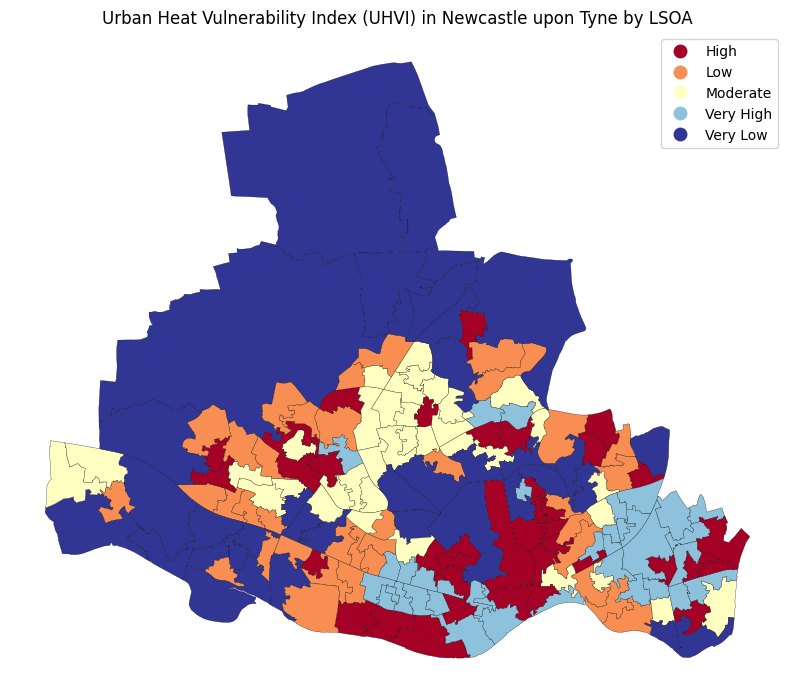

In [160]:
# 3. Map UHVI classes

fig, ax = plt.subplots(figsize=(10, 10))

lsoa.plot(
    column="uhvi_class",
    cmap="RdYlBu",
    categorical=True,
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

ax.set_title("Urban Heat Vulnerability Index (UHVI) in Newcastle upon Tyne by LSOA")
ax.axis("off")

plt.savefig(
    f"{figure_dir}/uhvi_newcastle_by_lsoa.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

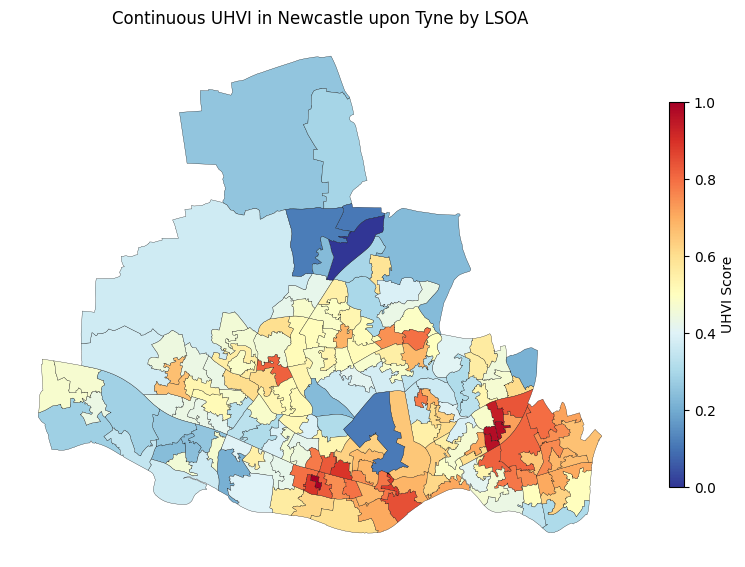

In [161]:
# Map continuous UHVI

fig, ax = plt.subplots(figsize=(10, 10))

lsoa.plot(
    column="uhvi",
    cmap="RdYlBu_r",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax,
    legend_kwds={
        "label": "UHVI Score",
        "shrink": 0.5,
        "aspect": 25
    }
)

ax.set_title("Continuous UHVI in Newcastle upon Tyne by LSOA")
ax.axis("off")

plt.savefig(
    f"{figure_dir}/uhvi_continuous_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Correlation analysis

In [162]:
# Correlation with UHVI

vars_to_check = [
    "lst_mean",
    "lst_p95",
    "hotspot_binary",
    "ndvi_mean",
    "ndbi_mean",
    "impervious_pct",
    "green_pct",
    "tree_canopy_pct",
    "road_density_km_per_km2",
    "built_up_density_proxy",
    "population_density",
    "age_65_pct",
    "age_75_pct",
    "disability_pct",
    "imd_score",
    "income_score",
    "health_deprivation_score",
    "uhvi"
]

available_vars = [v for v in vars_to_check if v in lsoa.columns]

corr = lsoa[available_vars].corr(numeric_only=True)

corr_with_uhvi = corr["uhvi"].sort_values(ascending=False)

display(corr_with_uhvi)

,uhvi
uhvi,1.000000
lst_mean,0.802205
hotspot_binary,0.722976
built_up_density_proxy,0.714743
impervious_pct,0.714743
ndbi_mean,0.707598
population_density,0.610876
road_density_km_per_km2,0.538878
lst_p95,0.519926
health_deprivation_score,0.230492


In [163]:
# Save correlation table

corr_with_uhvi.to_csv(
    f"{output_dir}/correlation_with_uhvi.csv"
)

print("Saved correlation table.")

Saved correlation table.


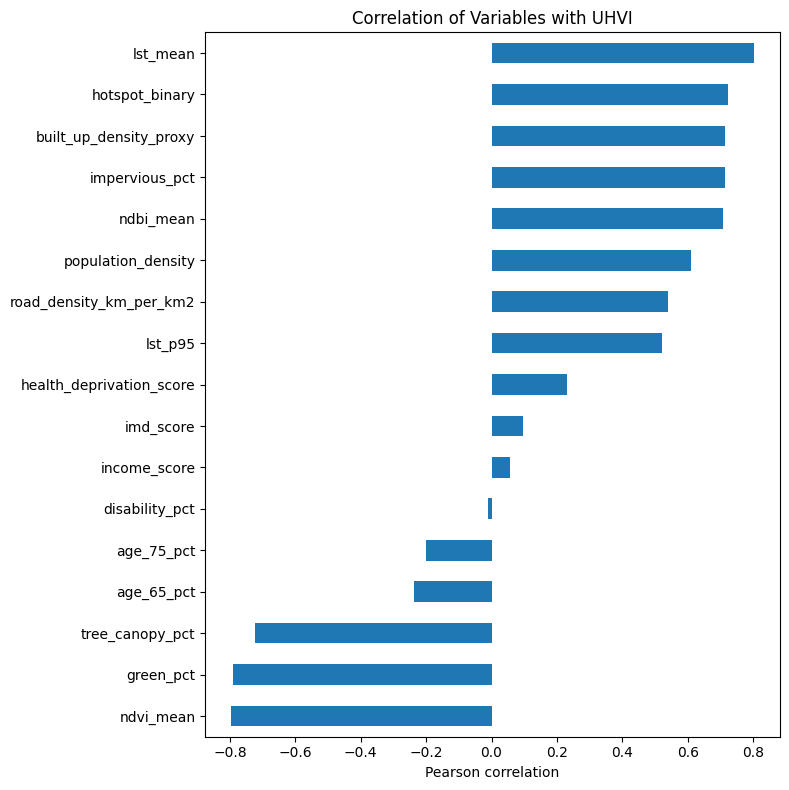

In [164]:
# Plot correlation with UHVI

corr_plot = corr_with_uhvi.drop("uhvi")

fig, ax = plt.subplots(figsize=(8, 8))

corr_plot.sort_values().plot(kind="barh", ax=ax)

ax.set_title("Correlation of Variables with UHVI")
ax.set_xlabel("Pearson correlation")

plt.tight_layout()

plt.savefig(
    f"{figure_dir}/correlation_with_uhvi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**2. XGBoost modelling and evaluation**

In [165]:
# Prepare features and target

feature_cols = [
    "lst_mean",
    "lst_p95",
    "hotspot_binary",
    "ndvi_mean",
    "ndbi_mean",
    "impervious_pct",
    "green_pct",
    "tree_canopy_pct",
    "road_density_km_per_km2",
    "built_up_density_proxy",
    "population_density",
    "age_65_pct",
    "age_75_pct",
    "disability_pct",
    "imd_score",
    "income_score",
    "health_deprivation_score"
]

feature_cols = [c for c in feature_cols if c in lsoa.columns]

model_df = lsoa[
    ["LSOA21CD", name_col, "uhvi", "geometry"] + feature_cols
].copy()

# Convert to numeric
for col in feature_cols + ["uhvi"]:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# Drop rows with missing model values
model_df = model_df.dropna(subset=feature_cols + ["uhvi"]).copy()

print("Rows for modelling:", len(model_df))
print("Features:", feature_cols)

Rows for modelling: 169
Features: ['lst_mean', 'lst_p95', 'hotspot_binary', 'ndvi_mean', 'ndbi_mean', 'impervious_pct', 'green_pct', 'tree_canopy_pct', 'road_density_km_per_km2', 'built_up_density_proxy', 'population_density', 'age_65_pct', 'age_75_pct', 'disability_pct', 'imd_score', 'income_score', 'health_deprivation_score']


In [166]:
# X and y

X = model_df[feature_cols]
y = model_df["uhvi"]

print(X.shape)
print(y.shape)

(169, 17)
(169,)


In [167]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 126
Testing rows: 43


In [168]:
# Train XGBoost regressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [169]:
# Evaluate model performance

y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model performance")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Model performance
MAE: 0.030301401092047254
RMSE: 0.03647333978809506
R²: 0.9599163945893068


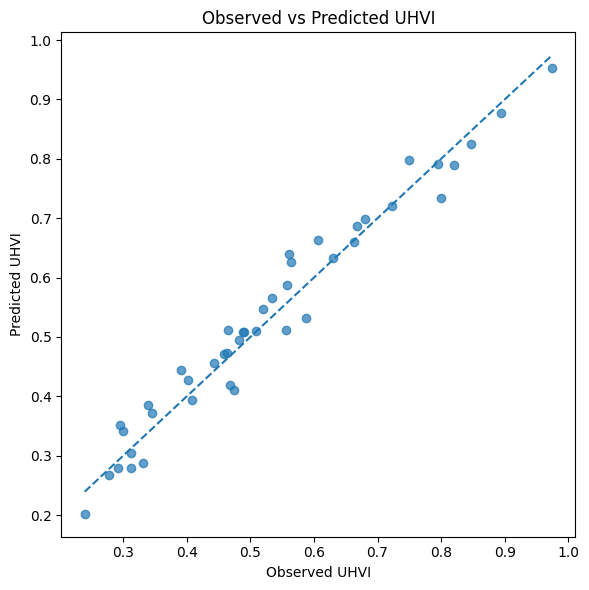

In [170]:
# Observed vs predicted plot

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, y_pred, alpha=0.7)

ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

ax.set_xlabel("Observed UHVI")
ax.set_ylabel("Predicted UHVI")
ax.set_title("Observed vs Predicted UHVI")

plt.tight_layout()

plt.savefig(
    f"{figure_dir}/observed_vs_predicted_uhvi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [171]:
# Cross-validation

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_r2 = cross_val_score(
    xgb_model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

cv_rmse = -cross_val_score(
    xgb_model,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

print("CV R²:", cv_r2)
print("Mean CV R²:", cv_r2.mean())

print("CV RMSE:", cv_rmse)
print("Mean CV RMSE:", cv_rmse.mean())

CV R²: [0.96379976 0.95855246 0.93641361 0.9251587  0.94055544]
Mean CV R²: 0.9448959916069333
CV RMSE: [0.02951212 0.03625979 0.03931587 0.05101196 0.04092755]
Mean CV RMSE: 0.03940545741057612


XGBoost model feature importance

In [172]:
# XGBoost feature importance

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance)

importance.to_csv(
    f"{output_dir}/xgboost_feature_importance.csv",
    index=False
)

,feature,importance
2,hotspot_binary,0.371145
0,lst_mean,0.260047
3,ndvi_mean,0.095590
7,tree_canopy_pct,0.094552
6,green_pct,0.064073
4,ndbi_mean,0.020369
1,lst_p95,0.017777
12,age_75_pct,0.016034
5,impervious_pct,0.014883
15,income_score,0.013006


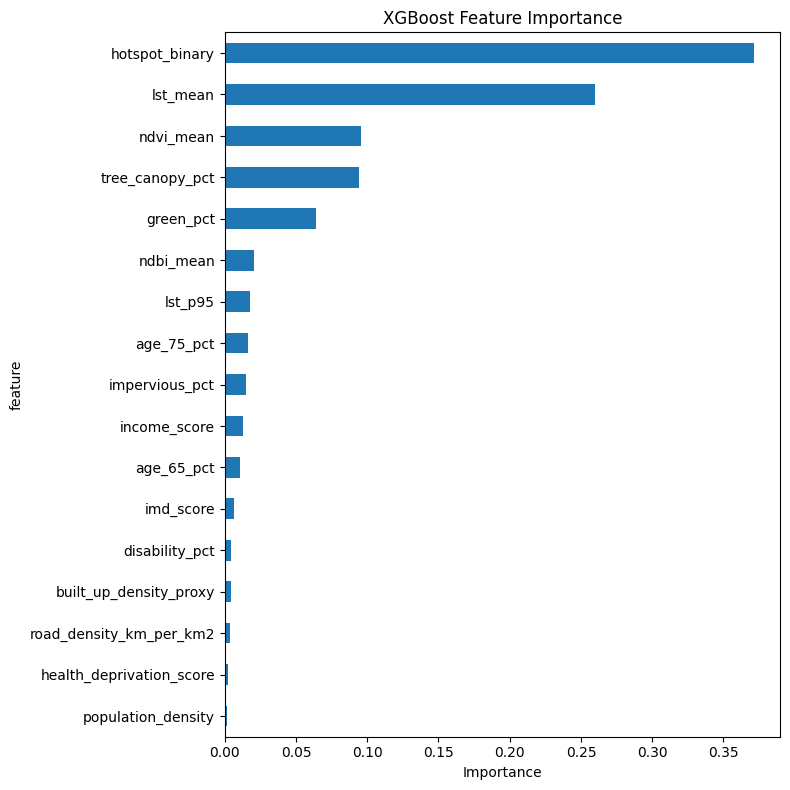

In [173]:
# Plot feature importance

fig, ax = plt.subplots(figsize=(8, 8))

importance.sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False,
    ax=ax
)

ax.set_title("XGBoost Feature Importance")
ax.set_xlabel("Importance")

plt.tight_layout()

plt.savefig(
    f"{figure_dir}/xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**3. SHAP GeoXAI analysis and visualization**

In [174]:
# SHAP explainability

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

print(np.array(shap_values).shape)

(169, 17)


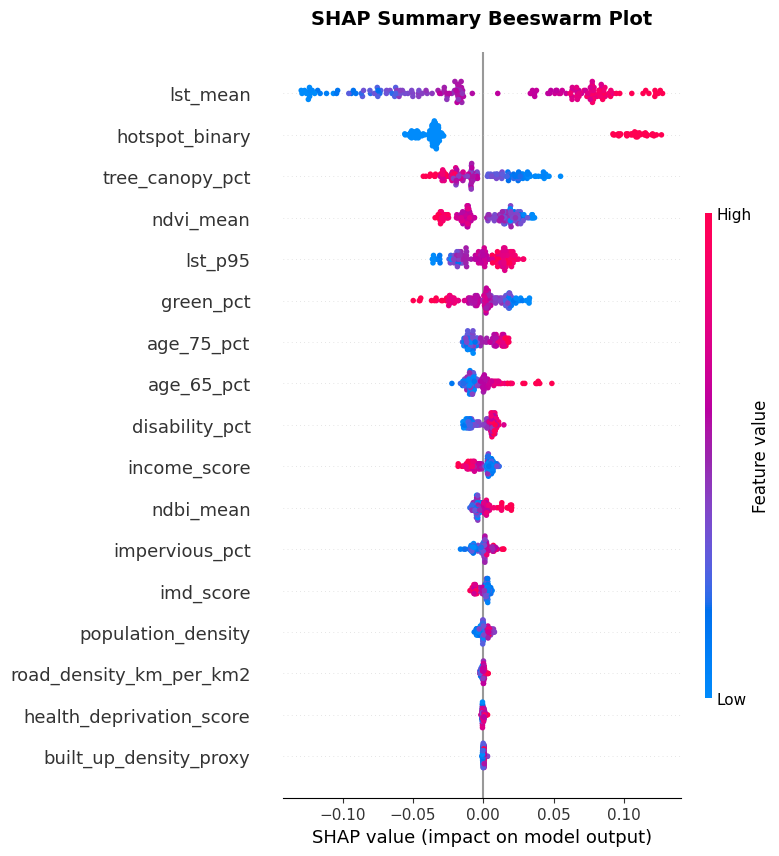

In [175]:
# SHAP summary beeswarm plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X,
    show=False
)

plt.title(
    "SHAP Summary Beeswarm Plot",
    fontsize=14,
    fontweight="bold",
    pad=20
)

fig = plt.gcf()

cbar_ax = fig.axes[-1]

cbar_ax.set_position([
    cbar_ax.get_position().x0,
    cbar_ax.get_position().y0 + 0.12,
    cbar_ax.get_position().width * 0.6,
    cbar_ax.get_position().height * 0.65
])

plt.savefig(
    f"{figure_dir}/shap_summary_beeswarm_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Create spatial SHAP maps

In [176]:
# Create SHAP values DataFrame

shap_df = pd.DataFrame(
    shap_values,
    columns=[f"shap_{col}" for col in feature_cols],
    index=model_df.index
)

model_df_shap = model_df.join(shap_df)

# Convert back to GeoDataFrame
model_gdf = gpd.GeoDataFrame(
    model_df_shap,
    geometry="geometry",
    crs=lsoa.crs
)

print(model_gdf.columns.tolist())

['LSOA21CD', 'LSOA21NM_x', 'uhvi', 'geometry', 'lst_mean', 'lst_p95', 'hotspot_binary', 'ndvi_mean', 'ndbi_mean', 'impervious_pct', 'green_pct', 'tree_canopy_pct', 'road_density_km_per_km2', 'built_up_density_proxy', 'population_density', 'age_65_pct', 'age_75_pct', 'disability_pct', 'imd_score', 'income_score', 'health_deprivation_score', 'shap_lst_mean', 'shap_lst_p95', 'shap_hotspot_binary', 'shap_ndvi_mean', 'shap_ndbi_mean', 'shap_impervious_pct', 'shap_green_pct', 'shap_tree_canopy_pct', 'shap_road_density_km_per_km2', 'shap_built_up_density_proxy', 'shap_population_density', 'shap_age_65_pct', 'shap_age_75_pct', 'shap_disability_pct', 'shap_imd_score', 'shap_income_score', 'shap_health_deprivation_score']


In [177]:
# Save SHAP GeoPackage

shap_gpkg = f"{output_dir}/newcastle_uhvi_shap_values.gpkg"

model_gdf.to_file(
    shap_gpkg,
    layer="shap_values",
    driver="GPKG"
)

print("Saved:", shap_gpkg)

Saved: /content/drive/MyDrive/LST_Project/outputs/newcastle_uhvi_shap_values.gpkg


In [178]:
# Map SHAP values for key drivers

def map_shap_feature(gdf, feature):

    fig, ax = plt.subplots(figsize=(10, 10))

    gdf.plot(
        column=f"shap_{feature}",
        cmap="RdYlBu_r",
        legend=True,
        edgecolor="black",
        linewidth=0.2,
        ax=ax,
        legend_kwds={
            "label": "SHAP Value",
            "shrink": 0.6,
            "aspect": 25
        }
    )

    ax.set_title(
        f"SHAP Contribution of {feature.replace('_', ' ').title()}",
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    ax.axis("off")

    plt.savefig(
        f"{figure_dir}/shap_top_5_driver_map_{feature}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

,feature,mean_abs_shap
0,lst_mean,0.067401
2,hotspot_binary,0.055783
7,tree_canopy_pct,0.020676
3,ndvi_mean,0.018645
1,lst_p95,0.014247
6,green_pct,0.014068
12,age_75_pct,0.009838
11,age_65_pct,0.008761
13,disability_pct,0.007759
15,income_score,0.006071


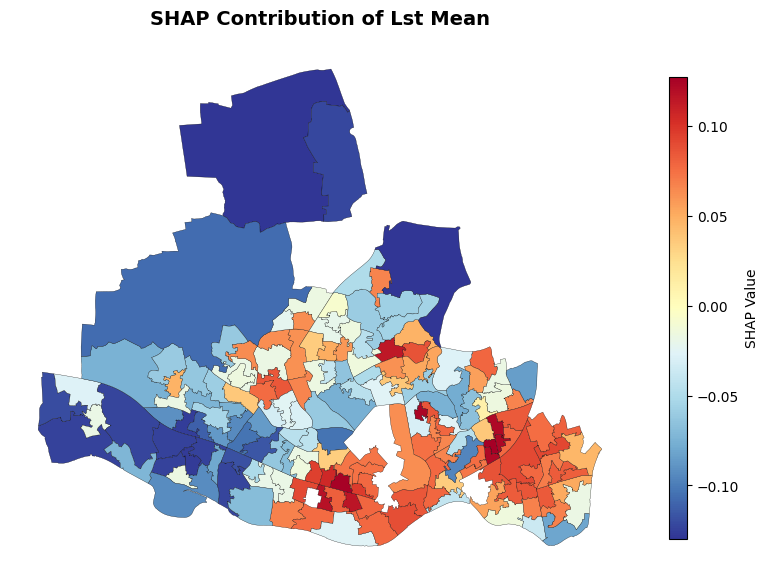

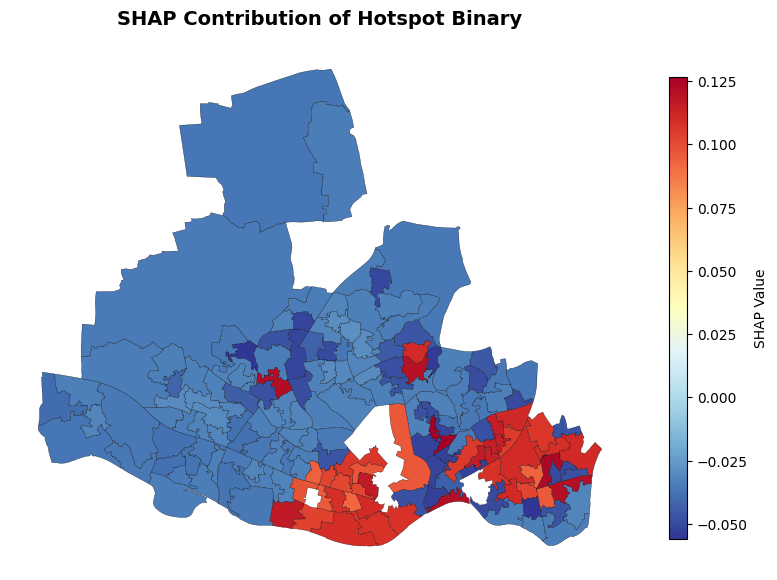

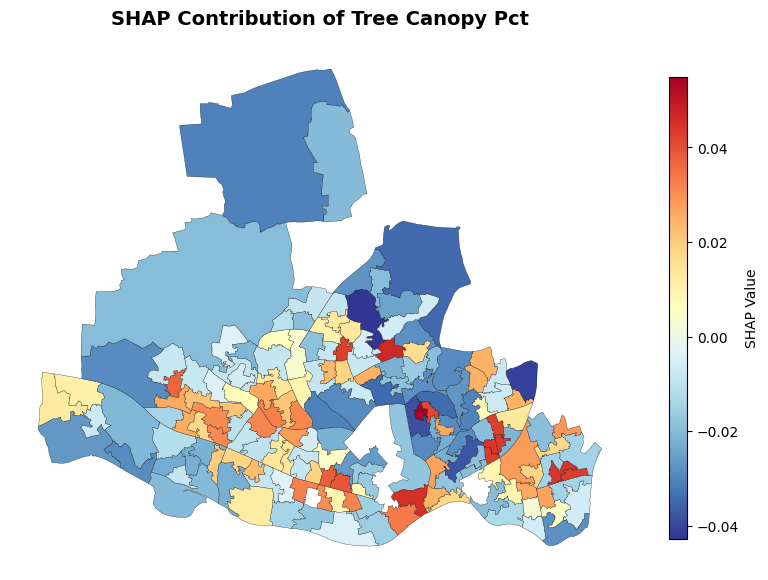

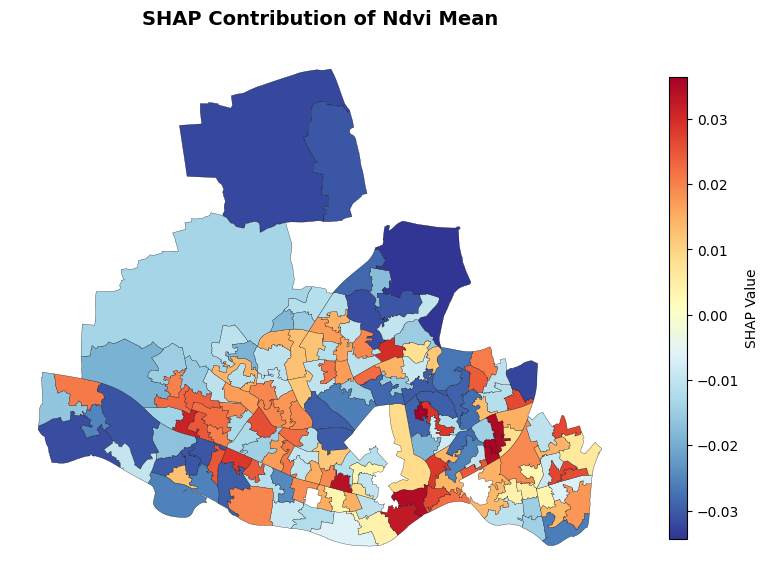

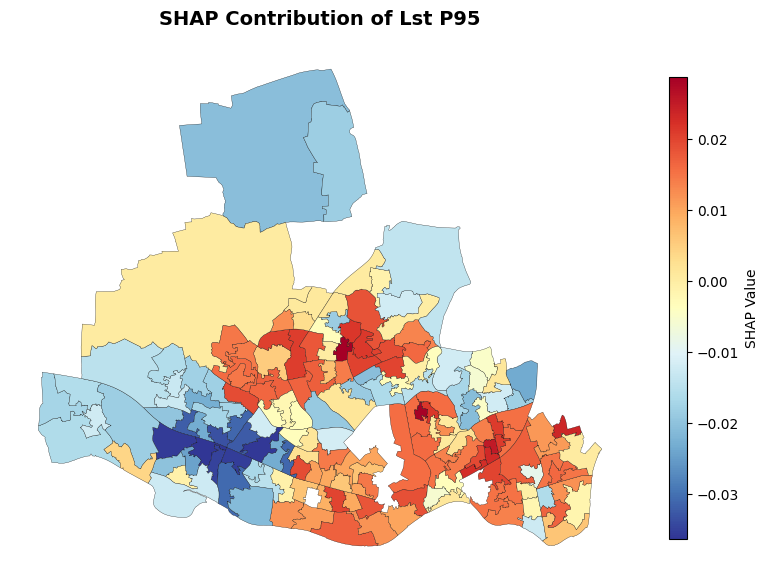

In [179]:
# Map top 5 SHAP drivers

mean_abs_shap = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(mean_abs_shap)

top5_features = mean_abs_shap["feature"].head(5).tolist()

for feature in top5_features:
    map_shap_feature(model_gdf, feature)

In [180]:
# Local explanation for highest UHVI LSOA

highest_idx = model_df["uhvi"].idxmax()

highest_row = model_df.loc[highest_idx]

print("Highest UHVI LSOA:")
print(highest_row[["LSOA21CD", name_col, "uhvi"]])

Highest UHVI LSOA:
LSOA21CD                     E01008361
LSOA21NM_x    Newcastle upon Tyne 018D
uhvi                          0.974381
Name: 69, dtype: object


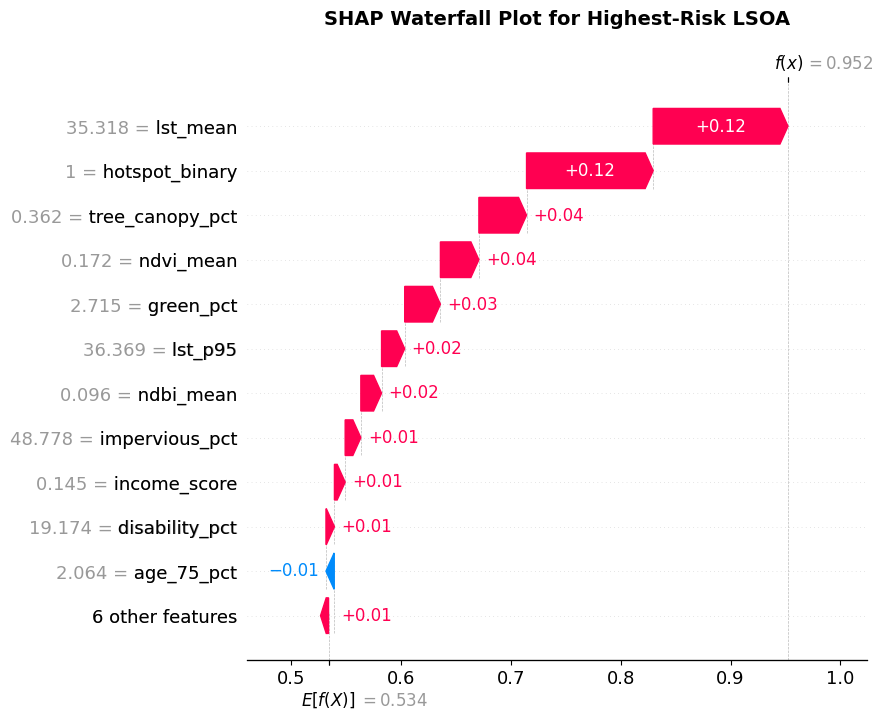

In [181]:
# SHAP waterfall plot for highest-risk LSOA

row_position = model_df.index.get_loc(highest_idx)

explanation = shap.Explanation(
    values=shap_values[row_position],
    base_values=explainer.expected_value,
    data=X.iloc[row_position],
    feature_names=feature_cols
)

shap.plots.waterfall(
    explanation,
    max_display=12,
    show=False
)

# Add title
plt.title(
    "SHAP Waterfall Plot for Highest-Risk LSOA",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.savefig(
    f"{figure_dir}/shap_waterfall_highest_uhvi_lsoa.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**4. Adaptation scenarios and visualization**

In [182]:
# Scenario 1: increase tree canopy by 20%

X_tree = X.copy()

if "tree_canopy_pct" in X_tree.columns:
    X_tree["tree_canopy_pct"] = np.minimum(
        X_tree["tree_canopy_pct"] * 1.20,
        100
    )

tree_pred = xgb_model.predict(X_tree)

model_gdf["uhvi_tree_canopy_20"] = tree_pred
model_gdf["uhvi_reduction_tree_20"] = (
    model_gdf["uhvi"] - model_gdf["uhvi_tree_canopy_20"]
)

model_gdf[
    [
        "LSOA21CD",
        name_col,
        "uhvi",
        "uhvi_tree_canopy_20",
        "uhvi_reduction_tree_20"
    ]
].sort_values("uhvi_reduction_tree_20", ascending=False).head(10)

,LSOA21CD,LSOA21NM_x,uhvi,uhvi_tree_canopy_20,uhvi_reduction_tree_20
108,E01008403,Newcastle upon Tyne 014D,0.474173,0.386412,0.087761
135,E01008433,Newcastle upon Tyne 020C,0.799069,0.733568,0.065502
15,E01008303,Newcastle upon Tyne 018A,0.819897,0.763898,0.056000
19,E01008309,Newcastle upon Tyne 002A,0.587103,0.531991,0.055113
114,E01008410,Newcastle upon Tyne 034B,0.468295,0.418412,0.049884
24,E01008315,Newcastle upon Tyne 012B,0.331313,0.282921,0.048393
8,E01008296,Newcastle upon Tyne 011A,0.816874,0.772016,0.044858
157,E01008457,Newcastle upon Tyne 004C,0.555477,0.511302,0.044175
153,E01008452,Newcastle upon Tyne 016D,0.312409,0.271690,0.040719
71,E01008363,Newcastle upon Tyne 012E,0.839082,0.799452,0.039630


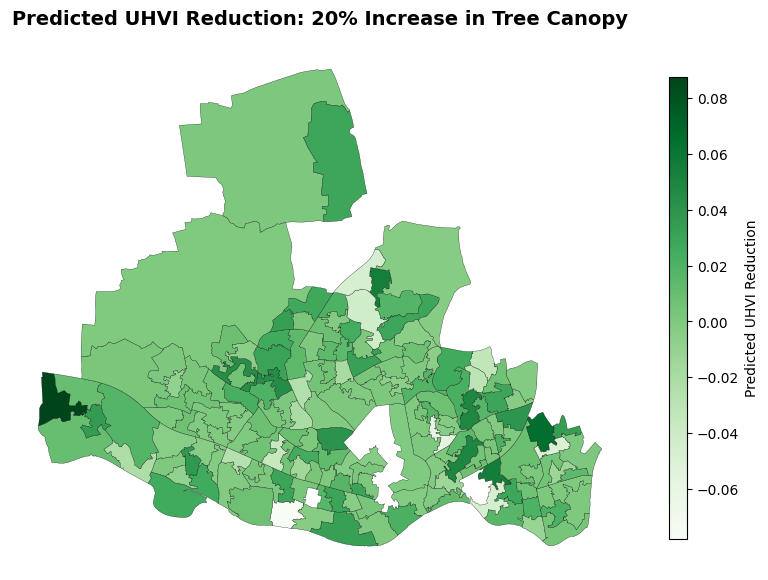

In [183]:
# Map tree canopy scenario benefit

fig, ax = plt.subplots(figsize=(10, 10))

model_gdf.plot(
    column="uhvi_reduction_tree_20",
    cmap="Greens",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax,
    legend_kwds={
        "label": "Predicted UHVI Reduction",
        "shrink": 0.6,   # shorter colour bar
        "aspect": 25     # thinner colour bar
    }
)

ax.set_title(
    "Predicted UHVI Reduction: 20% Increase in Tree Canopy",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.axis("off")

plt.savefig(
    f"{figure_dir}/scenario_tree_canopy_20_reduction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [184]:
# Scenario 2: increase greenspace by 20%

X_green = X.copy()

if "green_pct" in X_green.columns:
    X_green["green_pct"] = np.minimum(
        X_green["green_pct"] * 1.20,
        100
    )

green_pred = xgb_model.predict(X_green)

model_gdf["uhvi_green_20"] = green_pred
model_gdf["uhvi_reduction_green_20"] = (
    model_gdf["uhvi"] - model_gdf["uhvi_green_20"]
)

model_gdf[
    [
        "LSOA21CD",
        name_col,
        "uhvi",
        "uhvi_green_20",
        "uhvi_reduction_green_20"
    ]
].sort_values("uhvi_reduction_green_20", ascending=False).head(10)

,LSOA21CD,LSOA21NM_x,uhvi,uhvi_green_20,uhvi_reduction_green_20
135,E01008433,Newcastle upon Tyne 020C,0.799069,0.723526,0.075543
157,E01008457,Newcastle upon Tyne 004C,0.555477,0.483480,0.071997
24,E01008315,Newcastle upon Tyne 012B,0.331313,0.263858,0.067455
108,E01008403,Newcastle upon Tyne 014D,0.474173,0.406910,0.067263
19,E01008309,Newcastle upon Tyne 002A,0.587103,0.526839,0.060264
114,E01008410,Newcastle upon Tyne 034B,0.468295,0.411915,0.056380
113,E01008409,Newcastle upon Tyne 017D,0.390537,0.343791,0.046746
139,E01008437,Newcastle upon Tyne 041C,0.598043,0.552210,0.045833
15,E01008303,Newcastle upon Tyne 018A,0.819897,0.774118,0.045779
103,E01008398,Newcastle upon Tyne 022C,0.751884,0.709086,0.042798


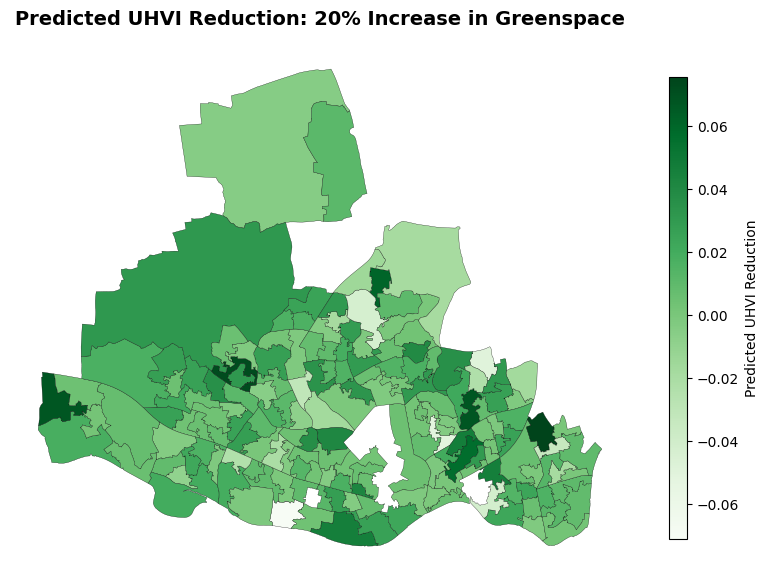

In [185]:
# Map greenspace scenario benefit

fig, ax = plt.subplots(figsize=(10, 10))

model_gdf.plot(
    column="uhvi_reduction_green_20",
    cmap="Greens",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax,
    legend_kwds={
        "label": "Predicted UHVI Reduction",
        "shrink": 0.6,   # smaller colour bar
        "aspect": 25     # thinner colour bar
    }
)

ax.set_title(
    "Predicted UHVI Reduction: 20% Increase in Greenspace",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.axis("off")

plt.savefig(
    f"{figure_dir}/scenario_green_20_reduction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [186]:
# Scenario 3: reduce impervious surface by 10%

X_imperv = X.copy()

if "impervious_pct" in X_imperv.columns:
    X_imperv["impervious_pct"] = np.maximum(
        X_imperv["impervious_pct"] * 0.90,
        0
    )

if "built_up_density_proxy" in X_imperv.columns:
    X_imperv["built_up_density_proxy"] = np.maximum(
        X_imperv["built_up_density_proxy"] * 0.90,
        0
    )

imperv_pred = xgb_model.predict(X_imperv)

model_gdf["uhvi_impervious_minus_10"] = imperv_pred
model_gdf["uhvi_reduction_impervious_10"] = (
    model_gdf["uhvi"] - model_gdf["uhvi_impervious_minus_10"]
)

model_gdf[
    [
        "LSOA21CD",
        name_col,
        "uhvi",
        "uhvi_impervious_minus_10",
        "uhvi_reduction_impervious_10"
    ]
].sort_values("uhvi_reduction_impervious_10", ascending=False).head(10)

,LSOA21CD,LSOA21NM_x,uhvi,uhvi_impervious_minus_10,uhvi_reduction_impervious_10
135,E01008433,Newcastle upon Tyne 020C,0.799069,0.730929,0.068141
108,E01008403,Newcastle upon Tyne 014D,0.474173,0.406622,0.067551
19,E01008309,Newcastle upon Tyne 002A,0.587103,0.525968,0.061135
114,E01008410,Newcastle upon Tyne 034B,0.468295,0.416913,0.051383
24,E01008315,Newcastle upon Tyne 012B,0.331313,0.287223,0.044090
157,E01008457,Newcastle upon Tyne 004C,0.555477,0.512803,0.042674
90,E01008382,Newcastle upon Tyne 021B,0.239448,0.202273,0.037175
153,E01008452,Newcastle upon Tyne 016D,0.312409,0.278865,0.033543
15,E01008303,Newcastle upon Tyne 018A,0.819897,0.790260,0.029637
134,E01008432,Newcastle upon Tyne 035B,0.754003,0.729936,0.024067


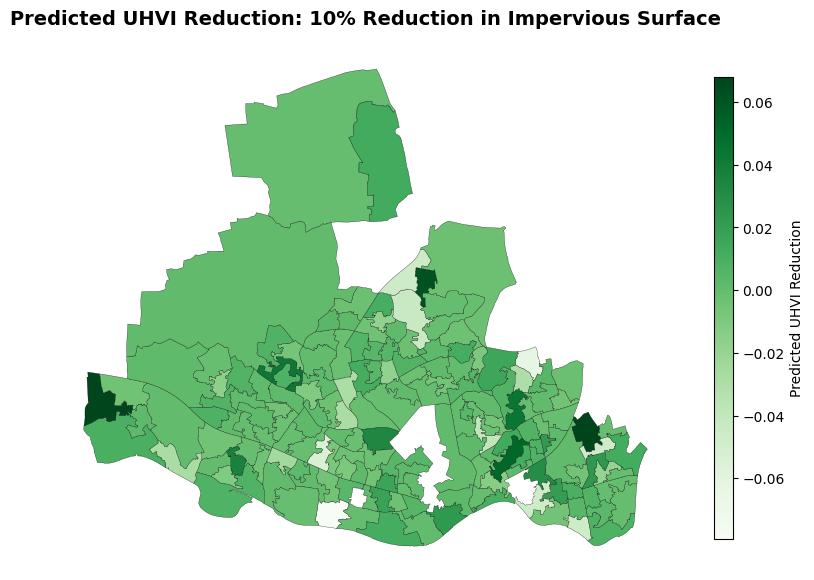

In [187]:
# Map impervious surface reduction scenario benefit

fig, ax = plt.subplots(figsize=(10, 10))

model_gdf.plot(
    column="uhvi_reduction_impervious_10",
    cmap="Greens",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax,
    legend_kwds={
        "label": "Predicted UHVI Reduction",
        "shrink": 0.6,   # shorter colour bar
        "aspect": 25     # thinner colour bar
    }
)

ax.set_title(
    "Predicted UHVI Reduction: 10% Reduction in Impervious Surface",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.axis("off")

plt.savefig(
    f"{figure_dir}/scenario_impervious_minus_10_reduction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [188]:
# Combined adaptation scenario

X_combined = X.copy()

if "tree_canopy_pct" in X_combined.columns:
    X_combined["tree_canopy_pct"] = np.minimum(
        X_combined["tree_canopy_pct"] * 1.20,
        100
    )

if "green_pct" in X_combined.columns:
    X_combined["green_pct"] = np.minimum(
        X_combined["green_pct"] * 1.20,
        100
    )

if "impervious_pct" in X_combined.columns:
    X_combined["impervious_pct"] = np.maximum(
        X_combined["impervious_pct"] * 0.90,
        0
    )

if "built_up_density_proxy" in X_combined.columns:
    X_combined["built_up_density_proxy"] = np.maximum(
        X_combined["built_up_density_proxy"] * 0.90,
        0
    )

combined_pred = xgb_model.predict(X_combined)

model_gdf["uhvi_combined"] = combined_pred
model_gdf["uhvi_reduction_combined"] = (
    model_gdf["uhvi"] - model_gdf["uhvi_combined"]
)

model_gdf[
    [
        "LSOA21CD",
        name_col,
        "uhvi",
        "uhvi_combined",
        "uhvi_reduction_combined"
    ]
].sort_values("uhvi_reduction_combined", ascending=False).head(10)

,LSOA21CD,LSOA21NM_x,uhvi,uhvi_combined,uhvi_reduction_combined
108,E01008403,Newcastle upon Tyne 014D,0.474173,0.379975,0.094198
139,E01008437,Newcastle upon Tyne 041C,0.598043,0.511284,0.086760
135,E01008433,Newcastle upon Tyne 020C,0.799069,0.720888,0.078182
41,E01008333,Newcastle upon Tyne 038E,0.749957,0.673937,0.076021
24,E01008315,Newcastle upon Tyne 012B,0.331313,0.257464,0.073849
103,E01008398,Newcastle upon Tyne 022C,0.751884,0.679128,0.072756
15,E01008303,Newcastle upon Tyne 018A,0.819897,0.747755,0.072142
157,E01008457,Newcastle upon Tyne 004C,0.555477,0.484982,0.070496
113,E01008409,Newcastle upon Tyne 017D,0.390537,0.321713,0.068824
64,E01008356,Newcastle upon Tyne 006C,0.514015,0.447546,0.066469


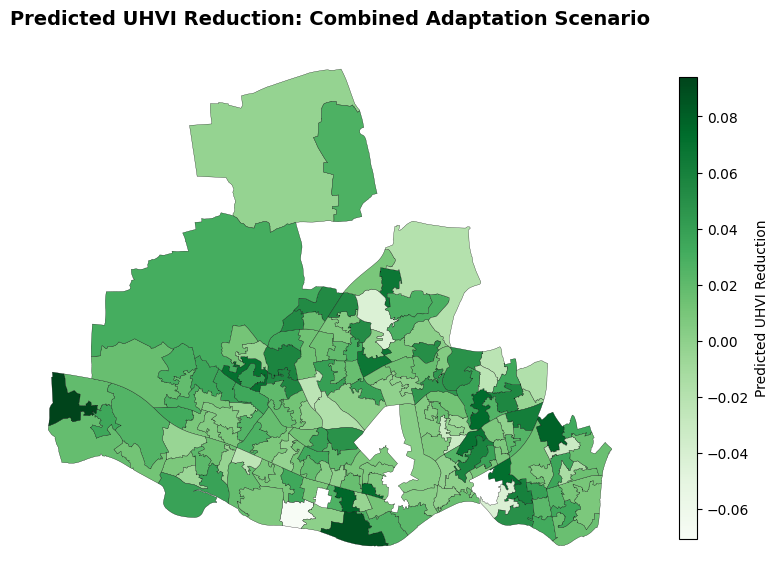

In [189]:
# Map combined adaptation scenario benefit

fig, ax = plt.subplots(figsize=(10, 10))

model_gdf.plot(
    column="uhvi_reduction_combined",
    cmap="Greens",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax,
    legend_kwds={
        "label": "Predicted UHVI Reduction",
        "shrink": 0.6,   # shorter colour bar
        "aspect": 25     # thinner colour bar
    }
)

ax.set_title(
    "Predicted UHVI Reduction: Combined Adaptation Scenario",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.axis("off")

plt.savefig(
    f"{figure_dir}/scenario_combined_reduction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**5. Intervention priority and visualization**

In [190]:
# Intervention priority score

def minmax_normalise(series):
    series = pd.to_numeric(series, errors="coerce")
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

model_gdf["uhvi_norm"] = minmax_normalise(model_gdf["uhvi"])
model_gdf["benefit_norm"] = minmax_normalise(
    model_gdf["uhvi_reduction_combined"]
)

model_gdf["intervention_priority"] = (
    model_gdf["uhvi_norm"] +
    model_gdf["benefit_norm"]
) / 2

model_gdf["priority_class"] = pd.qcut(
    model_gdf["intervention_priority"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

model_gdf["priority_class"].value_counts()

,count
priority_class,
Very Low,34
Low,34
High,34
Very High,34
Moderate,33


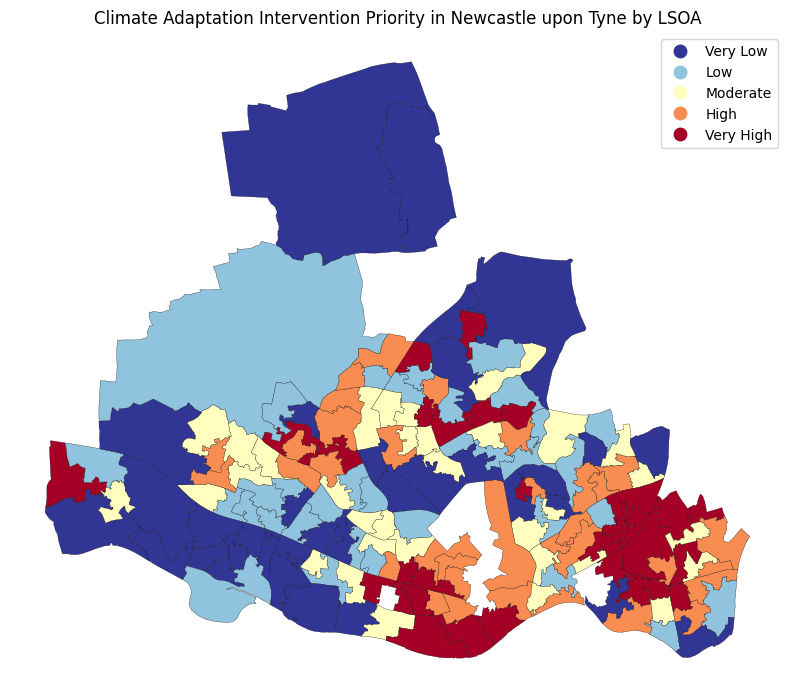

In [191]:
# Map intervention priority using

import pandas as pd
import matplotlib.pyplot as plt

priority_order = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

model_gdf["priority_class"] = pd.Categorical(
    model_gdf["priority_class"],
    categories=priority_order,
    ordered=True
)

fig, ax = plt.subplots(figsize=(10, 10))

model_gdf.plot(
    column="priority_class",
    cmap="RdYlBu_r",
    categorical=True,
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

ax.set_title(
    "Climate Adaptation Intervention Priority in Newcastle upon Tyne by LSOA"
)

ax.axis("off")

plt.savefig(
    f"{figure_dir}/intervention_priority_map_by_lsoa.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Save final GeoXAI scenario dataset

In [192]:
# Save final GeoXAI dataset

final_gpkg = f"{output_dir}/newcastle_geoxai_adaptation_scenarios.gpkg"
final_csv = f"{output_dir}/newcastle_geoxai_adaptation_scenarios.csv"

model_gdf.to_file(
    final_gpkg,
    layer="geoxai_scenarios",
    driver="GPKG"
)

model_gdf.drop(columns="geometry").to_csv(
    final_csv,
    index=False
)

print("Saved GeoPackage:", final_gpkg)
print("Saved CSV:", final_csv)

Saved GeoPackage: /content/drive/MyDrive/LST_Project/outputs/newcastle_geoxai_adaptation_scenarios.gpkg
Saved CSV: /content/drive/MyDrive/LST_Project/outputs/newcastle_geoxai_adaptation_scenarios.csv


In [193]:
# GeoXAI results and create a master datase

model_gdf["top_driver"] = (
    model_gdf[
        [c for c in model_gdf.columns if c.startswith("shap_")]
    ]
    .abs()
    .idxmax(axis=1)
)

model_gdf["top_driver"] = (
    model_gdf["top_driver"]
    .str.replace("shap_", "", regex=False)
)

output_geojson = (
    "/content/drive/MyDrive/LST_Project/outputs/"
    "newcastle_geoxai.geojson"
)

model_gdf.to_file(
    output_geojson,
    driver="GeoJSON"
)

print(output_geojson)

/content/drive/MyDrive/LST_Project/outputs/newcastle_geoxai.geojson
